In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

class State(TypedDict):
    text: str

def generate(state: State) -> State:
    return {"text": "some generated text"}

def check(state: State) -> str:
    if "good" in state["text"]:
        return "done"
    return "retry"

graph = StateGraph(State)
graph.add_node("generate", generate)
graph.add_edge(START, "generate")
graph.add_conditional_edges("generate", check, {"done": END, "retry": "generate"})

workflow = graph.compile()

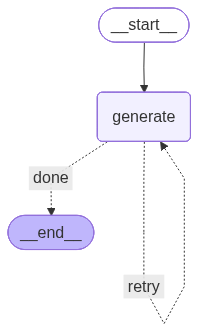

In [2]:
workflow

In [3]:
from typing import TypedDict, List

class State(TypedDict):
    tasks: List[str]
    completed: List[str]
    current_task: str

def pick_task(state: State) -> State:
    if state["tasks"]:
        current = state["tasks"].pop(0)
        return {"current_task": current, "tasks": state["tasks"]}
    return {"current_task": None}

def process_task(state: State) -> State:
    completed = state["completed"] + [state["current_task"]]
    return {"completed": completed}

def router(state: State) -> str:
    return "loop" if state["tasks"] else "finish"

graph = StateGraph(State)
graph.add_node("pick_task", pick_task)
graph.add_node("process_task", process_task)

graph.add_edge(START, "pick_task")
graph.add_edge("pick_task", "process_task")
graph.add_conditional_edges("process_task", router, {"loop": "pick_task", "finish": END})

workflow = graph.compile()

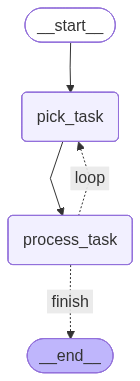

In [4]:
workflow

In [5]:
from langgraph.graph import MessagesState
from langchain.messages import SystemMessage, ToolMessage

def llm_call(state: MessagesState):
    response = llm_with_tools.invoke(
        [SystemMessage(content="You are a helpful assistant.")] + state["messages"]
    )
    return {"messages": [response]}

def tool_node(state: MessagesState):
    results = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        output = tool.invoke(tool_call["args"])
        results.append(ToolMessage(content=output, tool_call_id=tool_call["id"]))
    return {"messages": results}

def should_continue(state: MessagesState) -> str:
    last_message = state["messages"][-1]
    return "tool_node" if last_message.tool_calls else END

graph = StateGraph(MessagesState)
graph.add_node("llm_call", llm_call)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_call")
graph.add_conditional_edges("llm_call", should_continue, {"tool_node": "tool_node", END: END})
graph.add_edge("tool_node", "llm_call")

workflow = graph.compile()

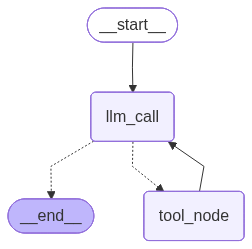

In [6]:
workflow

In [1]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Literal
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

load_dotenv()

class JokeState(TypedDict):
    topic: str
    joke: str
    feedback: str
    grade: str
    iteration: int
    max_iteration: int

class Feedback(BaseModel):
    grade: Literal["funny", "not_funny"] = Field(description="Is the joke funny or not")
    feedback: str = Field(description="How to improve the joke if it is not funny")

model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)
evaluator_model = model.with_structured_output(Feedback)

def generate_joke(state: JokeState) -> JokeState:
    if state.get("feedback"):
        prompt = f"Write a short joke about {state['topic']}. Improve it based on this feedback: {state['feedback']}"
    else:
        prompt = f"Write a short joke about {state['topic']}"
    joke = model.invoke(prompt).content
    return {"joke": joke, "iteration": state.get("iteration", 0) + 1}

def evaluate_joke(state: JokeState) -> JokeState:
    result = evaluator_model.invoke(f"Grade this joke as funny or not_funny, and explain why:\n\n{state['joke']}")
    return {"grade": result.grade, "feedback": result.feedback}

def route_after_evaluation(state: JokeState) -> Literal["done", "retry"]:
    if state["grade"] == "funny":
        return "done"
    if state["iteration"] >= state["max_iteration"]:
        return "done"
    return "retry"

graph = StateGraph(JokeState)
graph.add_node("generate_joke", generate_joke)
graph.add_node("evaluate_joke", evaluate_joke)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "evaluate_joke")
graph.add_conditional_edges(
    "evaluate_joke",
    route_after_evaluation,
    {"done": END, "retry": "generate_joke"},
)

workflow = graph.compile()

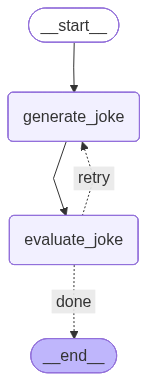

In [2]:
workflow

In [3]:

if __name__ == "__main__":
    initial_state = {
        "topic": "software engineers debugging code",
        "joke": "",
        "feedback": "",
        "grade": "",
        "iteration": 0,
        "max_iteration": 3,
    }
    result = workflow.invoke(initial_state)

    print(f"Final joke ({result['iteration']} attempt(s)):\n{result['joke']}")
    print(f"\nFinal grade: {result['grade']}")
    print(f"Final feedback: {result['feedback']}")

Final joke (1 attempt(s)):


Why do programmers love debugging in the dark?  
Because that way the bugs can’t see them either—just like in a horror movie, but the “monster” is a missing semicolon.

Final grade: funny
Final feedback: This is a solid programmer joke that earns its humor through clever wordplay. The pun on 'monster' becoming 'missing semicolon' is legitimately witty and plays on a very relatable programmer experience—spending hours hunting down a tiny syntax error. The horror movie comparison, while slightly forced, adds a creative layer that makes it more than just a simple pun. For programmers who've experienced the frustration of a missing semicolon causing hours of debugging, the joke lands well. It's not side-splitting humor, but it's a cut above typical programming jokes—the kind that would get a chuckle in a dev team chat. The joke does lose some impact with non-programmers who won't fully appreciate the semicolon frustration, but for its intended audience, it's fu

In [4]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Literal, List, Optional
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END

load_dotenv()

class ReviewResult(BaseModel):
    sentiment: Literal["positive", "neutral", "negative"] = Field(description="Sentiment of the review")

class QueueState(TypedDict):
    pending_reviews: List[str]
    current_review: Optional[str]
    results: List[dict]

model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)
classifier_model = model.with_structured_output(ReviewResult)

def pick_review(state: QueueState) -> QueueState:
    pending = state["pending_reviews"]
    if not pending:
        return {"current_review": None}
    next_review = pending[0]
    remaining = pending[1:]
    return {"current_review": next_review, "pending_reviews": remaining}

def classify_review(state: QueueState) -> QueueState:
    review = state["current_review"]
    result = classifier_model.invoke(f"Classify the sentiment of this review:\n\n{review}")
    updated_results = state["results"] + [{"review": review, "sentiment": result.sentiment}]
    return {"results": updated_results}

def route_after_classify(state: QueueState) -> Literal["loop", "finish"]:
    return "loop" if state["pending_reviews"] else "finish"

graph = StateGraph(QueueState)
graph.add_node("pick_review", pick_review)
graph.add_node("classify_review", classify_review)

graph.add_edge(START, "pick_review")
graph.add_edge("pick_review", "classify_review")
graph.add_conditional_edges(
    "classify_review",
    route_after_classify,
    {"loop": "pick_review", "finish": END},
)

workflow = graph.compile()


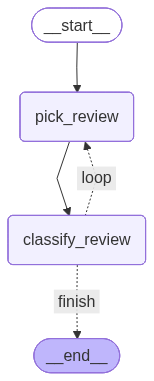

In [5]:
workflow

In [6]:
if __name__ == "__main__":
    initial_state = {
        "pending_reviews": [
            "The app crashes every time I try to upload a photo, very frustrating.",
            "Works exactly as expected, no complaints.",
            "Absolutely love the new dashboard, so much cleaner now!",
        ],
        "current_review": None,
        "results": [],
    }
    result = workflow.invoke(initial_state)

    print(f"Processed {len(result['results'])} reviews:\n")
    for item in result["results"]:
        print(f"[{item['sentiment']}] {item['review']}")

Processed 3 reviews:

[negative] The app crashes every time I try to upload a photo, very frustrating.
[positive] Works exactly as expected, no complaints.
[positive] Absolutely love the new dashboard, so much cleaner now!


In [8]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from langchain_core.tools import tool
from langchain_core.messages import SystemMessage, ToolMessage, HumanMessage
from langgraph.graph import StateGraph, START, END, MessagesState

load_dotenv()

@tool
def add(a: float, b: float) -> float:
    """Add two numbers together."""
    return a + b

@tool
def multiply(a: float, b: float) -> float:
    """Multiply two numbers together."""
    return a * b

@tool
def get_shipping_cost(weight_kg: float) -> str:
    """Look up shipping cost for a package given its weight in kilograms."""
    rate_per_kg = 4.5
    cost = weight_kg * rate_per_kg
    return f"Shipping cost for {weight_kg}kg is ${cost:.2f}"

tools = [add, multiply, get_shipping_cost]
tools_by_name = {t.name: t for t in tools}

model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)
model_with_tools = model.bind_tools(tools)

def llm_call(state: MessagesState) -> MessagesState:
    response = model_with_tools.invoke(
        [SystemMessage(content="You are a helpful assistant. Use tools when you need exact calculations or lookups.")]
        + state["messages"]
    )
    return {"messages": [response]}

def tool_node(state: MessagesState) -> MessagesState:
    last_message = state["messages"][-1]
    results = []
    for tool_call in last_message.tool_calls:
        tool_fn = tools_by_name[tool_call["name"]]
        output = tool_fn.invoke(tool_call["args"])
        results.append(ToolMessage(content=str(output), tool_call_id=tool_call["id"]))
    return {"messages": results}

def should_continue(state: MessagesState) -> str:
    last_message = state["messages"][-1]
    if last_message.tool_calls:
        return "tool_node"
    return "end"

graph = StateGraph(MessagesState)
graph.add_node("llm_call", llm_call)
graph.add_node("tool_node", tool_node)

graph.add_edge(START, "llm_call")
graph.add_conditional_edges(
    "llm_call",
    should_continue,
    {"tool_node": "tool_node", "end": END},
)
graph.add_edge("tool_node", "llm_call")

workflow = graph.compile(checkpointer=None)


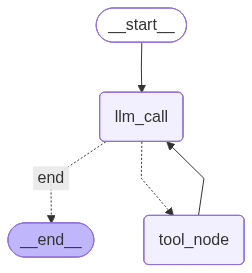

In [9]:
workflow

In [10]:

if __name__ == "__main__":
    result = workflow.invoke(
        {
            "messages": [
                HumanMessage(
                    content="I have a package that weighs 3.2kg. What's the shipping cost, "
                    "and if I send 4 of these packages, what's the total shipping cost?"
                )
            ]
        },
        config={"recursion_limit": 15},
    )

    print("Full conversation:\n")
    for message in result["messages"]:
        role = message.__class__.__name__
        content = message.content if message.content else f"(tool call: {message.tool_calls})"
        print(f"[{role}] {content}\n")

Full conversation:

[HumanMessage] I have a package that weighs 3.2kg. What's the shipping cost, and if I send 4 of these packages, what's the total shipping cost?

[AIMessage] (tool call: [{'name': 'get_shipping_cost', 'args': {'weight_kg': 3.2}, 'id': 'chatcmpl-tool-a616b66f69fe330d', 'type': 'tool_call'}])

[ToolMessage] Shipping cost for 3.2kg is $14.40

[AIMessage] (tool call: [{'name': 'multiply', 'args': {'a': 14.4, 'b': 4}, 'id': 'chatcmpl-tool-afd4e91cc59df926', 'type': 'tool_call'}])

[ToolMessage] 57.6

[AIMessage] 

Here's the breakdown:

1. **Single package (3.2kg):** $14.40 shipping cost
2. **4 packages total:** $57.60 (4 × $14.40)

So if you send 4 packages weighing 3.2kg each, your total shipping cost will be **$57.60**.



In [11]:
import os
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.types import interrupt, Command

load_dotenv()

class DraftState(TypedDict):
    topic: str
    draft: str
    feedback: str
    approved: bool
    iteration: int
    max_iteration: int

model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)

def write_draft(state: DraftState) -> DraftState:
    if state.get("feedback"):
        prompt = f"Write a short marketing email about {state['topic']}. Revise based on this feedback: {state['feedback']}"
    else:
        prompt = f"Write a short marketing email about {state['topic']}"
    draft = model.invoke(prompt).content
    return {"draft": draft, "iteration": state.get("iteration", 0) + 1}

def human_review(state: DraftState) -> DraftState:
    decision = interrupt({
        "message": "Review this draft. Approve it or send it back with feedback.",
        "draft": state["draft"],
        "iteration": state["iteration"],
    })
    if decision["action"] == "approve":
        return {"approved": True}
    return {"approved": False, "feedback": decision.get("feedback", "")}

def route_after_review(state: DraftState) -> Literal["done", "revise"]:
    if state["approved"]:
        return "done"
    if state["iteration"] >= state["max_iteration"]:
        return "done"
    return "revise"

graph = StateGraph(DraftState)
graph.add_node("write_draft", write_draft)
graph.add_node("human_review", human_review)

graph.add_edge(START, "write_draft")
graph.add_edge("write_draft", "human_review")
graph.add_conditional_edges(
    "human_review",
    route_after_review,
    {"done": END, "revise": "write_draft"},
)

workflow = graph.compile(checkpointer=MemorySaver())


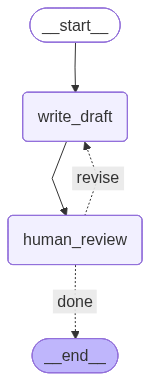

In [12]:
workflow

In [13]:

if __name__ == "__main__":
    config = {"configurable": {"thread_id": "draft-1"}}
    initial_state = {
        "topic": "our new AI-powered expense tracker",
        "draft": "",
        "feedback": "",
        "approved": False,
        "iteration": 0,
        "max_iteration": 3,
    }

    result = workflow.invoke(initial_state, config=config)

    simulated_human_decisions = [
        {"action": "revise", "feedback": "Make it shorter and add a clear call to action."},
        {"action": "approve"},
    ]

    for decision in simulated_human_decisions:
        if "__interrupt__" not in result:
            break

        payload = result["__interrupt__"][0].value
        print(f"\n--- Paused for human review (attempt {payload['iteration']}) ---")
        print(payload["draft"])
        print(f"\nHuman decision: {decision}")

        result = workflow.invoke(Command(resume=decision), config=config)

    print(f"\n--- Final draft (approved={result['approved']}) ---")
    print(result["draft"])


--- Paused for human review (attempt 1) ---


**Subject:** Track Smarter, Not Harder – Meet Your New AI Expense Companion 🚀

---

Hi [Name],

Managing expenses just got smarter.

Introducing **ExpenseAI** – the intelligent expense tracker that does the heavy lifting for you. Here's how our AI-powered features simplify your financial life:

✅ **Auto-categorization** – Transactions are sorted instantly, no manual entry required.
✅ **Smart Insights** – Get personalized spending analysis and budget recommendations.
✅ **Receipt Scanning** – Just snap a photo; our AI extracts the details.
✅ **Forecast & Alerts** – Stay ahead with predictive spending insights and outlier detection.

Stop drowning in receipts and start making smarter financial decisions.

**Try ExpenseAI free for 14 days →** [Sign Up Now]

Best regards,
[Your Name]
[Your Company]

---

*P.S. Limited-time offer: Get 20% off your first year with code AI20.*

---

This email is ready to customize with your specific product name,

In [2]:
import os
import operator
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Annotated, List
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

load_dotenv()

class SectionPlan(BaseModel):
    section_titles: List[str] = Field(description="3 to 4 short section titles for the report")

class ReportState(TypedDict):
    topic: str
    section_titles: List[str]
    completed_sections: Annotated[List[dict], operator.add]
    final_report: str

class WorkerState(TypedDict):
    section: str
    topic: str
    completed_sections: Annotated[List[dict], operator.add]

model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"),
)
planner_model = model.with_structured_output(SectionPlan)

def plan_sections(state: ReportState) -> ReportState:
    result = planner_model.invoke(f"Plan 3 short section titles for a report on: {state['topic']}")
    return {"section_titles": result.section_titles}

def assign_workers(state: ReportState) -> List[Send]:
    return [
        Send("write_section", {"section": title, "topic": state["topic"]})
        for title in state["section_titles"]
    ]

def write_section(state: WorkerState) -> ReportState:
    prompt = f"Write a short paragraph for the '{state['section']}' section of a report about {state['topic']}."
    content = model.invoke(prompt).content
    return {"completed_sections": [{"title": state["section"], "content": content}]}

def combine_sections(state: ReportState) -> ReportState:
    ordered = sorted(
        state["completed_sections"],
        key=lambda s: state["section_titles"].index(s["title"]),
    )
    report = f"# Report: {state['topic']}\n\n"
    for section in ordered:
        report += f"## {section['title']}\n{section['content']}\n\n"
    return {"final_report": report}

graph = StateGraph(ReportState)
graph.add_node("plan_sections", plan_sections)
graph.add_node("write_section", write_section)
graph.add_node("combine_sections", combine_sections)

graph.add_edge(START, "plan_sections")
graph.add_conditional_edges("plan_sections", assign_workers, ["write_section"])
graph.add_edge("write_section", "combine_sections")
graph.add_edge("combine_sections", END)

workflow = graph.compile()


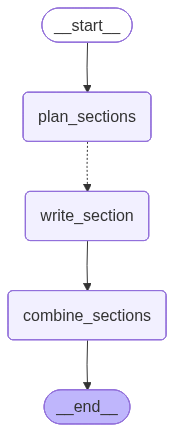

In [3]:
workflow

In [4]:

if __name__ == "__main__":
    result = workflow.invoke({
        "topic": "the benefits of remote work for small teams",
        "section_titles": [],
        "completed_sections": [],
        "final_report": "",
    })

    print(f"Sections planned: {result['section_titles']}\n")
    print(result["final_report"])

Sections planned: ['Cost Savings and Financial Benefits', 'Increased Productivity and Flexibility', 'Access to Broader Talent Pools']

# Report: the benefits of remote work for small teams

## Cost Savings and Financial Benefits


Remote work can dramatically cut a small team’s operating overhead by removing the need for a dedicated office lease, utilities, and routine maintenance—often saving tens of thousands of dollars per year. Employees who work from home also eliminate commuting costs, parking fees, and reimbursements for meals or travel, further reducing the company’s indirect expenses. Additionally, reduced use of office supplies, printing, and on‑site amenities lowers miscellaneous expenditures, while lower turnover and absenteeism translate into savings on recruiting and training costs. Together, these financial benefits can improve profit margins and free up capital for growth‑oriented initiatives.

## Increased Productivity and Flexibility




Remote work enables small team

In [5]:
if __name__ == "__main__":
    result = workflow.invoke({
        "topic": "How Learning new things using ai chatbots and ai agents accelarated",
        "section_titles": [],
        "completed_sections": [],
        "final_report": "",
    })

    print(f"Sections planned: {result['section_titles']}\n")
    print(result["final_report"])

Sections planned: ['AI-Powered Learning: Reshaping Education', 'Chatbots as Personalized Learning Assistants', 'Accelerating Skill Acquisition with AI Agents']

# Report: How Learning new things using ai chatbots and ai agents accelarated

## AI-Powered Learning: Reshaping Education


# AI-Powered Learning: Reshaping Education

AI-powered learning is fundamentally transforming education by providing personalized, accessible, and interactive learning experiences through chatbots and AI agents. These intelligent tools adapt to individual learning styles and paces, offering instant feedback and tailored explanations that were previously only available through one-on-one tutoring. Students can engage with AI assistants 24/7, breaking down geographical and temporal barriers to education while accelerating the learning process by up to 40% according to recent studies. Furthermore, AI agents serve as tireless learning companions, helping learners overcome frustration, fill knowledge gaps, and

`Send(node, values)`in LangGraph is a messenger that routes a dict payload to a named node, enabling dynamic fan-out (map-reduce) and parallel task execution. [Read more →](https://medium.com/@syeedmdtalha/understanding-send-in-langgraph-573f4d7c9a0c)

In [ ]:
import os
import operator
from dotenv import load_dotenv
from langchain_nebius import ChatNebius
from typing_extensions import TypedDict
from typing import Literal, List, Annotated
from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

load_dotenv()

class TopicClassification(BaseModel):
    content_goal: Literal["promotional", "educational", "announcement"] = Field(
        description="The overall goal of the content"
    )
    needs_research: bool = Field(
        description="True if the topic needs a few factual talking points gathered before writing"
    )

class DraftEvaluation(BaseModel):
    grade: Literal["approved", "needs_revision"] = Field(description="Is the draft good enough to publish")
    feedback: str = Field(description="What to improve if not approved")

class ContentState(TypedDict):
    topic: str
    content_goal: str
    needs_research: bool
    research_notes: str
    platforms: List[str]
    platform_drafts: Annotated[List[dict], operator.add]
    final_posts: dict

class PlatformState(TypedDict):
    platform: str
    post_topic: str
    post_goal: str
    post_research_notes: str
    draft: str
    feedback: str
    grade: str
    iteration: int
    max_iteration: int
    platform_drafts: Annotated[List[dict], operator.add]

model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=os.getenv("NEBIUS_API_KEY"), # pyright: ignore[reportArgumentType]
)
classifier_model = model.with_structured_output(TopicClassification)
evaluator_model = model.with_structured_output(DraftEvaluation)

STYLE_GUIDE = {
    "twitter": "Keep it under 280 characters, punchy, at most 2 hashtags.",
    "linkedin": "Professional tone, 3 to 5 sentences, minimal hashtags.",
    "instagram": "Casual and visual tone, can use emojis and a few hashtags.",
}

def classify_topic(state: ContentState) -> ContentState:
    prompt = f"""Classify this social media topic: "{state['topic']}"

Decide the content goal (promotional, educational, or announcement) and whether
it needs a few factual talking points researched before writing posts about it."""
    result = classifier_model.invoke(prompt)
    return {"content_goal": result.content_goal, "needs_research": result.needs_research} # pyright: ignore[reportAttributeAccessIssue, reportReturnType]

def route_after_classify(state: ContentState) -> Literal["research", "skip_research"]:
    return "research" if state["needs_research"] else "skip_research"

def research_topic(state: ContentState) -> ContentState:
    prompt = f"Give 3 to 4 short factual talking points about: {state['topic']}"
    notes = model.invoke(prompt).content
    return {"research_notes": notes} # type: ignore

def plan_platforms(state: ContentState) -> ContentState:
    return {"platforms": ["twitter", "linkedin", "instagram"]} # type: ignore

def assign_platform_workers(state: ContentState) -> List[Send]:
    return [
        Send(
            "platform_pipeline",
            {
                "platform": platform,
                "post_topic": state["topic"],
                "post_goal": state["content_goal"],
                "post_research_notes": state.get("research_notes", ""),
                "draft": "",
                "feedback": "",
                "grade": "",
                "iteration": 0,
                "max_iteration": 2,
            },
        )
        for platform in state["platforms"]
    ]

def generate_draft(state: PlatformState) -> PlatformState:
    guide = STYLE_GUIDE.get(state["platform"], "")
    if state.get("feedback"):
        prompt = f"""Rewrite this {state['platform']} post about {state['post_topic']}.
Feedback to address: {state['feedback']}
Style guide: {guide}
Research notes: {state.get('post_research_notes', 'none')}"""
    else:
        prompt = f"""Write a {state['platform']} post about {state['post_topic']}.
Content goal: {state['post_goal']}
Style guide: {guide}
Research notes: {state.get('post_research_notes', 'none')}"""
    draft = model.invoke(prompt).content
    return {"draft": draft, "iteration": state.get("iteration", 0) + 1} # type: ignore

def evaluate_draft(state: PlatformState) -> PlatformState:
    prompt = f"Evaluate this {state['platform']} post for quality and fit for the platform:\n\n{state['draft']}"
    result = evaluator_model.invoke(prompt)
    return {"grade": result.grade, "feedback": result.feedback} # type: ignore

def route_after_evaluate(state: PlatformState) -> Literal["approved", "retry"]:
    if state["grade"] == "approved":
        return "approved"
    if state["iteration"] >= state["max_iteration"]:
        return "approved"
    return "retry"

def record_result(state: PlatformState) -> PlatformState:
    return {
        "platform_drafts": [ 
            {"platform": state["platform"], "content": state["draft"], "iterations": state["iteration"]} # type: ignore
        ]
    }

def combine_results(state: ContentState) -> ContentState:
    final_posts = {item["platform"]: item["content"] for item in state["platform_drafts"]}
    return {"final_posts": final_posts} # type: ignore

def build_platform_pipeline():
    pipeline = StateGraph(PlatformState)
    pipeline.add_node("generate_draft", generate_draft)
    pipeline.add_node("evaluate_draft", evaluate_draft)
    pipeline.add_node("record_result", record_result)

    pipeline.add_edge(START, "generate_draft")
    pipeline.add_edge("generate_draft", "evaluate_draft")
    pipeline.add_conditional_edges(
        "evaluate_draft",
        route_after_evaluate,
        {"approved": "record_result", "retry": "generate_draft"},
    )
    pipeline.add_edge("record_result", END)
    return pipeline.compile()

platform_pipeline = build_platform_pipeline()

graph = StateGraph(ContentState)
graph.add_node("classify_topic", classify_topic)
graph.add_node("research_topic", research_topic)
graph.add_node("plan_platforms", plan_platforms)
graph.add_node("platform_pipeline", platform_pipeline)
graph.add_node("combine_results", combine_results)

graph.add_edge(START, "classify_topic")
graph.add_conditional_edges(
    "classify_topic",
    route_after_classify,
    {"research": "research_topic", "skip_research": "plan_platforms"},
)
graph.add_edge("research_topic", "plan_platforms")
graph.add_conditional_edges("plan_platforms", assign_platform_workers, ["platform_pipeline"])
graph.add_edge("platform_pipeline", "combine_results")
graph.add_edge("combine_results", END)

workflow = graph.compile()

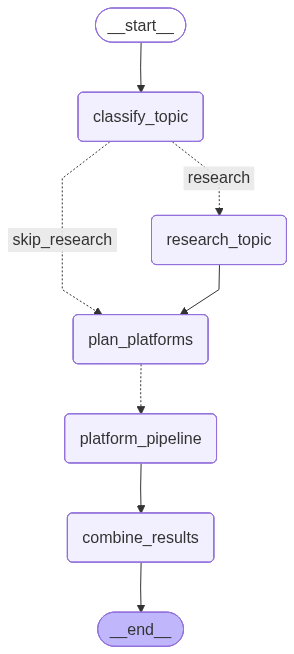

In [2]:
workflow

In [ ]:
if __name__ == "__main__":
    result = workflow.invoke({
        "topic": "our new AI-powered expense tracking feature launching next week",
        "content_goal": "",
        "needs_research": False,
        "research_notes": "",
        "platforms": [],
        "platform_drafts": [],
        "final_posts": {},
    })

    print(f"Content goal: {result['content_goal']}")
    print(f"Research notes: {result['research_notes'] or '(none needed)'}\n")

    for platform, content in result["final_posts"].items():
        print(f"--- {platform} ---")
        print(content)
        print()

In [3]:

import os
import asyncio
from dotenv import load_dotenv
from pydantic import SecretStr
from langchain_nebius import ChatNebius
from langchain_mcp_adapters.client import MultiServerMCPClient
from typing_extensions import TypedDict, NotRequired, Required
from typing import Literal, Any
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage

load_dotenv()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# State
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Your original fields untouched. Only additions:
#   - messages  -> scratchpad for the research tool-calling loop (TinyFish MCP)
#   - research  -> the plain-text research summary handed to write_draft
class DraftState(TypedDict, total=False):
    topic: Required[str]
    draft: NotRequired[str]
    iteration: Required[int]
    max_iteration: Required[int]
    messages: NotRequired[list[AnyMessage]]
    research: NotRequired[str]


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Model (unchanged)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=SecretStr(os.getenv("NEBIUS_API_KEY", "")),
)

# ── TinyFish MCP client ──
# https://agent.tinyfish.ai/mcp exposes tools such as `search`, `fetch_content`,
# and `run_web_automation`. Loaded once, tools are bound to the model only
# for the research phase of the graph.
RESEARCH_SYSTEM_PROMPT = (
    "You are a research assistant. Use the available web search and fetch "
    "tools to gather 3-5 concrete, current facts about the user's topic that "
    "would make a marketing email more credible (stats, recent news, product "
    "details). Once you have enough, reply with a short plain-text bullet "
    "summary and stop calling tools."
)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Nodes
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def make_research_node(llm_with_tools):
    """── research entry node ──
    Seeds the message scratchpad and makes the first model call, which may
    emit tool_calls against the TinyFish MCP tools.
    """
    async def start_research(state: DraftState) -> DraftState:
        system = SystemMessage(content=RESEARCH_SYSTEM_PROMPT)
        human = HumanMessage(content=f"Research this topic: {state['topic']}")
        response = await llm_with_tools.ainvoke([system, human])
        return {"messages": [system, human, response]}
    return start_research


def make_research_loop_node(llm_with_tools):
    """── research continuation node ──
    Re-invokes the model with full history (including ToolMessages appended
    by the ToolNode) so it can call another tool or hand back a summary.
    This is the standard LangGraph tool-calling iterative loop.
    """
    async def call_research_model(state: DraftState) -> DraftState:
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}
    return call_research_model


def finalize_research(state: DraftState) -> DraftState:
    """── collapse the tool-calling transcript into a research summary ──"""
    last = state["messages"][-1]
    research_text = last.content if isinstance(last.content, str) else str(last.content)
    return {"research": research_text}


def write_draft(state: DraftState) -> DraftState:
    research_context = (
        f"\n\nUse this research to ground the email:\n{state['research']}"
        if state.get("research") else ""
    )
    if state.get("draft"):
        prompt = (
            f"Here is a draft marketing email about {state['topic']}:\n\n"
            f"{state['draft']}\n\n"
            f"Improve it further — tighten the copy, strengthen the hook, "
            f"and make it more persuasive.{research_context}"
        )
    else:
        prompt = f"Write a short marketing email about {state['topic']}{research_context}"
    draft = model.invoke(prompt).content
    return {"draft": draft, "iteration": state.get("iteration", 0) + 1}


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Routing
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# No human-in-the-loop step. write_draft just loops on itself until
# max_iteration is hit, then ends.

def route_after_draft(state: DraftState) -> Literal["done", "revise"]:
    if state["iteration"] >= state["max_iteration"]:
        return "done"
    return "revise"


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Async graph factory
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MCP tool discovery is async (it opens an HTTP session against
# agent.tinyfish.ai), so the graph is assembled inside an async factory
# instead of at import time. This is the standard pattern from
# langchain-mcp-adapters when tools need to be loaded before `add_node`.

async def build_graph():
    mcp_client = MultiServerMCPClient(
        {
            "tinyfish": {
                "url": "https://agent.tinyfish.ai/mcp",
                "transport": "streamable_http",
            }
        }
    )
    tools = await mcp_client.get_tools()
    llm_with_tools = model.bind_tools(tools)

    graph = StateGraph(DraftState)

    graph.add_node("start_research", make_research_node(llm_with_tools))
    graph.add_node("research_tools", ToolNode(tools))
    graph.add_node("call_research_model", make_research_loop_node(llm_with_tools))
    graph.add_node("finalize_research", finalize_research)
    graph.add_node("write_draft", write_draft)

    graph.add_edge(START, "start_research")

    # ── iterative tool-calling loop ──
    # tools_condition inspects the last AIMessage: if it contains tool_calls,
    # route to the ToolNode; otherwise the model is done and we finalize.
    graph.add_conditional_edges(
        "start_research",
        tools_condition,
        {"tools": "research_tools", "__end__": "finalize_research"},
    )
    graph.add_edge("research_tools", "call_research_model")
    graph.add_conditional_edges(
        "call_research_model",
        tools_condition,
        {"tools": "research_tools", "__end__": "finalize_research"},
    )

    graph.add_edge("finalize_research", "write_draft")

    # ── self-revising draft loop ──
    # write_draft loops back into itself, improving the draft each pass,
    # until max_iteration is reached.
    graph.add_conditional_edges(
        "write_draft",
        route_after_draft,
        {"done": END, "revise": "write_draft"},
    )

    return graph.compile(checkpointer=MemorySaver())


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Usage
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Script usage (python content_pipeline.py):
#   Just run the file — the __main__ block below handles it.
#
# Notebook usage (Jupyter / Colab):
#   Do NOT run this file as one cell — the `if __name__ == "__main__"` block
#   will hit "RuntimeError: asyncio.run() cannot be called from a running
#   event loop", because the notebook kernel already has a loop running.
#
#   Instead, split it into two cells:
#     Cell 1: paste everything above this comment (imports, state, nodes,
#             build_graph) — do NOT include the __main__ block.
#     Cell 2:
#         workflow = await build_graph()
#         config = {"configurable": {"thread_id": "1"}}
#         result = await workflow.ainvoke(
#             {"topic": "our new eco-friendly water bottle", "max_iteration": 3},
#             config=config,
#         )
#         print(result["draft"])
#
#   Top-level await works natively in Jupyter/Colab cells — no nest_asyncio
#   or other patching needed.

async def main():
    workflow = await build_graph()
    config: Any = {"configurable": {"thread_id": "1"}}

    result = await workflow.ainvoke(
        {"topic": "our new eco-friendly water bottle", "max_iteration": 3},
        config=config,
    )

    print(result["draft"])


if __name__ == "__main__":
    loop = asyncio.get_event_loop()
    if loop.is_running():
        # In interactive environments (Jupyter/Colab) avoid calling asyncio.run
        print(
            "Detected running event loop; in notebooks, `await build_graph()` and "
            "`await workflow.ainvoke(...)` from a cell instead of running this file."
        )
    else:
        asyncio.run(main())
from dotenv import load_dotenv
from pydantic import SecretStr
from langchain_nebius import ChatNebius
from langchain_mcp_adapters.client import MultiServerMCPClient
from typing_extensions import TypedDict, NotRequired
from typing import Literal
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage

load_dotenv()

# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# State
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Your original fields untouched. Only additions:
#   - messages  -> scratchpad for the research tool-calling loop (TinyFish MCP)
#   - research  -> the plain-text research summary handed to write_draft
class DraftState(TypedDict, total=False):
    topic: str
    draft: str
    iteration: int
    max_iteration: int
    messages: NotRequired[list[AnyMessage]]
    research: NotRequired[str]


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Model (unchanged)
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
model = ChatNebius(
    model="MiniMaxAI/MiniMax-M2.5",
    api_key=SecretStr(os.getenv("NEBIUS_API_KEY", "")),
)

# ── TinyFish MCP client ──
# https://agent.tinyfish.ai/mcp exposes tools such as `search`, `fetch_content`,
# and `run_web_automation`. Loaded once, tools are bound to the model only
# for the research phase of the graph.
RESEARCH_SYSTEM_PROMPT = (
    "You are a research assistant. Use the available web search and fetch "
    "tools to gather 3-5 concrete, current facts about the user's topic that "
    "would make a marketing email more credible (stats, recent news, product "
    "details). Once you have enough, reply with a short plain-text bullet "
    "summary and stop calling tools."
)


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Nodes
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

def make_research_node(llm_with_tools):
    """── research entry node ──
    Seeds the message scratchpad and makes the first model call, which may
    emit tool_calls against the TinyFish MCP tools.
    """
    async def start_research(state: DraftState) -> DraftState:
        system = SystemMessage(content=RESEARCH_SYSTEM_PROMPT)
        human = HumanMessage(content=f"Research this topic: {state['topic']}")
        response = await llm_with_tools.ainvoke([system, human])
        return {"messages": [system, human, response]}
    return start_research


def make_research_loop_node(llm_with_tools):
    """── research continuation node ──
    Re-invokes the model with full history (including ToolMessages appended
    by the ToolNode) so it can call another tool or hand back a summary.
    This is the standard LangGraph tool-calling iterative loop.
    """
    async def call_research_model(state: DraftState) -> DraftState:
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}
    return call_research_model


def finalize_research(state: DraftState) -> DraftState:
    """── collapse the tool-calling transcript into a research summary ──"""
    last = state["messages"][-1]
    research_text = last.content if isinstance(last.content, str) else str(last.content)
    return {"research": research_text}


def write_draft(state: DraftState) -> DraftState:
    research_context = (
        f"\n\nUse this research to ground the email:\n{state['research']}"
        if state.get("research") else ""
    )
    if state.get("draft"):
        prompt = (
            f"Here is a draft marketing email about {state['topic']}:\n\n"
            f"{state['draft']}\n\n"
            f"Improve it further — tighten the copy, strengthen the hook, "
            f"and make it more persuasive.{research_context}"
        )
    else:
        prompt = f"Write a short marketing email about {state['topic']}{research_context}"
    draft = model.invoke(prompt).content
    return {"draft": draft, "iteration": state.get("iteration", 0) + 1}


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Routing
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# No human-in-the-loop step. write_draft just loops on itself until
# max_iteration is hit, then ends.

def route_after_draft(state: DraftState) -> Literal["done", "revise"]:
    if state["iteration"] >= state["max_iteration"]:
        return "done"
    return "revise"


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Async graph factory
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# MCP tool discovery is async (it opens an HTTP session against
# agent.tinyfish.ai), so the graph is assembled inside an async factory
# instead of at import time. This is the standard pattern from
# langchain-mcp-adapters when tools need to be loaded before `add_node`.

async def build_graph():
    mcp_client = MultiServerMCPClient(
        {
            "tinyfish": {
                "url": "https://agent.tinyfish.ai/mcp",
                "transport": "streamable_http",
            }
        }
    )
    tools = await mcp_client.get_tools()
    llm_with_tools = model.bind_tools(tools)

    graph = StateGraph(DraftState)

    graph.add_node("start_research", make_research_node(llm_with_tools))
    graph.add_node("research_tools", ToolNode(tools))
    graph.add_node("call_research_model", make_research_loop_node(llm_with_tools))
    graph.add_node("finalize_research", finalize_research)
    graph.add_node("write_draft", write_draft)

    graph.add_edge(START, "start_research")

    # ── iterative tool-calling loop ──
    # tools_condition inspects the last AIMessage: if it contains tool_calls,
    # route to the ToolNode; otherwise the model is done and we finalize.
    graph.add_conditional_edges(
        "start_research",
        tools_condition,
        {"tools": "research_tools", "__end__": "finalize_research"},
    )
    graph.add_edge("research_tools", "call_research_model")
    graph.add_conditional_edges(
        "call_research_model",
        tools_condition,
        {"tools": "research_tools", "__end__": "finalize_research"},
    )

    graph.add_edge("finalize_research", "write_draft")

    # ── self-revising draft loop ──
    # write_draft loops back into itself, improving the draft each pass,
    # until max_iteration is reached.
    graph.add_conditional_edges(
        "write_draft",
        route_after_draft,
        {"done": END, "revise": "write_draft"},
    )

    return graph.compile(checkpointer=MemorySaver())


# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Usage
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# Script usage (python content_pipeline.py):
#   Just run the file — the __main__ block below handles it.
#
# Notebook usage (Jupyter / Colab):
#   Do NOT run this file as one cell — the `if __name__ == "__main__"` block
#   will hit "RuntimeError: asyncio.run() cannot be called from a running
#   event loop", because the notebook kernel already has a loop running.
#
#   Instead, split it into two cells:
#     Cell 1: paste everything above this comment (imports, state, nodes,
#             build_graph) — do NOT include the __main__ block.
#     Cell 2:
#         workflow = await build_graph()
#         config = {"configurable": {"thread_id": "1"}}
#         result = await workflow.ainvoke(
#             {"topic": "our new eco-friendly water bottle", "max_iteration": 3},
#             config=config,
#         )
#         print(result["draft"])
#
#   Top-level await works natively in Jupyter/Colab cells — no nest_asyncio
#   or other patching needed.

async def main():
    workflow = await build_graph()
    config = {"configurable": {"thread_id": "1"}}

    result = await workflow.ainvoke(
        {"topic": "our new eco-friendly water bottle", "max_iteration": 3},
        config=config,
    )

    print(result["draft"])


if __name__ == "__main__":
    try:
        asyncio.run(main())
    except RuntimeError as e:
        if "running event loop" in str(e):
            raise RuntimeError(
                "This script was run inside an environment that already has "
                "an asyncio event loop (e.g. a Jupyter/Colab notebook). "
                "Don't run this file as a single cell — instead `await "
                "build_graph()` and `await workflow.ainvoke(...)` directly "
                "in a notebook cell. See the usage comment above main()."
            ) from e
        raise

Detected running event loop; in notebooks, `await build_graph()` and `await workflow.ainvoke(...)` from a cell instead of running this file.


RuntimeError: This script was run inside an environment that already has an asyncio event loop (e.g. a Jupyter/Colab notebook). Don't run this file as a single cell — instead `await build_graph()` and `await workflow.ainvoke(...)` directly in a notebook cell. See the usage comment above main().

In [ ]:
import os
import asyncio
from dotenv import load_dotenv
from pydantic import SecretStr
from langchain_nebius import ChatNebius
from langchain_mcp_adapters.client import MultiServerMCPClient
from typing_extensions import TypedDict, NotRequired
from typing import Literal, Any
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver
from langchain_core.messages import AnyMessage, SystemMessage, HumanMessage

load_dotenv()

# ====================== STATE ======================
class DraftState(TypedDict, total=False):
    topic: str
    draft: NotRequired[str]
    iteration: NotRequired[int]
    max_iteration: int
    messages: NotRequired[list[AnyMessage]]
    research: NotRequired[str]


# ====================== MODEL ======================
model = ChatNebius(
    model="MiniMaxAI/MiniMax-M.2.5",
    api_key=SecretStr(os.getenv("NEBIUS_API_KEY", "")),
)

RESEARCH_SYSTEM_PROMPT = (
    "You are a research assistant. Use the available web search and fetch "
    "tools to gather 3-5 concrete, current facts about the user's topic that "
    "would make a marketing email more credible (stats, recent news, product "
    "details). Once you have enough, reply with a short plain-text bullet "
    "summary and stop calling tools."
)


# ====================== NODES ======================
def make_research_node(llm_with_tools):
    async def start_research(state: DraftState) -> DraftState:
        system = SystemMessage(content=RESEARCH_SYSTEM_PROMPT)
        human = HumanMessage(content=f"Research this topic: {state['topic']}")
        response = await llm_with_tools.ainvoke([system, human])
        return {"messages": [system, human, response]}
    return start_research


def make_research_loop_node(llm_with_tools):
    async def call_research_model(state: DraftState) -> DraftState:
        response = await llm_with_tools.ainvoke(state["messages"])
        return {"messages": [response]}
    return call_research_model


def finalize_research(state: DraftState) -> DraftState:
    last = state["messages"][-1]
    research_text = last.content if isinstance(last.content, str) else str(last.content)
    return {"research": research_text}


def write_draft(state: DraftState) -> DraftState:
    research_context = (
        f"\n\nUse this research to ground the email:\n{state['research']}"
        if state.get("research") else ""
    )
    if state.get("draft"):
        prompt = (
            f"Here is a draft marketing email about {state['topic']}:\n\n"
            f"{state['draft']}\n\n"
            f"Improve it further — tighten the copy, strengthen the hook, "
            f"and make it more persuasive.{research_context}"
        )
    else:
        prompt = f"Write a short marketing email about {state['topic']}{research_context}"
    
    draft = model.invoke(prompt).content
    return {"draft": draft, "iteration": state.get("iteration", 0) + 1}


def route_after_draft(state: DraftState) -> Literal["done", "revise"]:
    if state.get("iteration", 0) >= state["max_iteration"]:
        return "done"
    return "revise"


# ====================== BUILD GRAPH ======================
async def build_graph():
    mcp_client = MultiServerMCPClient({
        "tinyfish": {
            "url": "https://agent.tinyfish.ai/mcp",
            "transport": "streamable_http",
        }
    })
    
    tools = await mcp_client.get_tools()
    llm_with_tools = model.bind_tools(tools)

    graph = StateGraph(DraftState)

    graph.add_node("start_research", make_research_node(llm_with_tools))
    graph.add_node("research_tools", ToolNode(tools))
    graph.add_node("call_research_model", make_research_loop_node(llm_with_tools))
    graph.add_node("finalize_research", finalize_research)
    graph.add_node("write_draft", write_draft)

    graph.add_edge(START, "start_research")

    graph.add_conditional_edges(
        "start_research",
        tools_condition,
        {"tools": "research_tools", "__end__": "finalize_research"}
    )
    graph.add_edge("research_tools", "call_research_model")
    graph.add_conditional_edges(
        "call_research_model",
        tools_condition,
        {"tools": "research_tools", "__end__": "finalize_research"}
    )

    graph.add_edge("finalize_research", "write_draft")

    graph.add_conditional_edges(
        "write_draft",
        route_after_draft,
        {"done": END, "revise": "write_draft"}
    )

    return graph.compile(checkpointer=MemorySaver())

In [ ]:
# Run this cell after Cell 1
workflow = await build_graph()
from langchain_core.runnables import RunnableConfig
config:RunnableConfig = {"configurable": {"thread_id": "1"}}

result = await workflow.ainvoke(
    {
        "topic": "our new eco-friendly water bottle",
        "max_iteration": 3
    },
    config=config
)

print(result["draft"])